# Binney et al. (2013) Waypoint Planning — Full Demo

This notebook demonstrates the complete Binney-style informative path planning pipeline:

1. **Scenario selection** — DataProvider, product, region, time, variable
2. **Graph construction** — WaypointGraph over the region with visualization
3. **Node + edge sampling** — Deterministic sampling function `h`
4. **Covariance backends** — Kernel (RBF) and empirical covariance
5. **GRG offline** — Plan once with full budget
6. **GRG receding-horizon** — Plan–execute–replan loop
7. **Baseline comparisons** — Greedy myopic, random walk, lawnmower
8. **Dense-grid evaluation** — RMSE/MAE on evaluation grid

## 1. Setup and path configuration

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
for p in [
    'oceanbench-core',
    'oceanbench-env',
    'oceanbench-models',
    'oceanbench-tasks',
    'oceanbench-bench',
    'oceanbench-viz',
    'oceanbench-policies',
    'oceanbench-data-provider',
]:
    d = ROOT / p
    if d.exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False})

## 2. Scenario selection

Define product, region, time window, and variable. Load data via `DataProvider.subset()`.

In [2]:
from oceanbench_data_provider import DataProvider

PRODUCT_ID = "copernicus_phy_reanalysis_001_030"
REGION = {"lon": [-92, -86], "lat": [22, 28]}
TIME_WINDOW = ("2014-01-01", "2014-01-07")
VARIABLE = "temp"

provider = DataProvider()
ds = provider.subset(
    product_id=PRODUCT_ID,
    region=REGION,
    time=TIME_WINDOW,
    variables=[VARIABLE],
    depth_opts=None,
    target_grid=None,
    overwrite=False,
)

print(f"Loaded subset: {ds.dims}")

Loaded subset: FrozenMappingWarningOnValuesAccess({'time': 7, 'depth': 50, 'lat': 73, 'lon': 73})


## 3. Graph construction and visualization

Build a `WaypointGraph` over the region and visualize nodes and edges.

In [3]:
from oceanbench_core import WaypointGraph

region = {
    "lat_min": REGION["lat"][0],
    "lat_max": REGION["lat"][1],
    "lon_min": REGION["lon"][0],
    "lon_max": REGION["lon"][1],
}

graph = WaypointGraph.grid(
    region=region,
    n_lat=5,
    n_lon=5,
    speed_mps=1.0,
    seed=0,
)

print(f"Graph: {graph.n_nodes} nodes, {graph.n_edges} edges")

Graph: 25 nodes, 40 edges


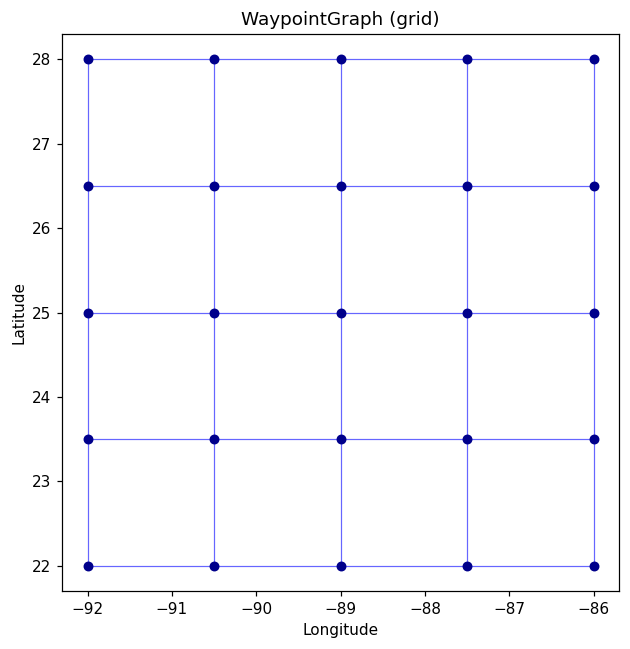

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for u, v in graph.graph.edges():
    lat_u, lon_u = graph.node_coords(u)
    lat_v, lon_v = graph.node_coords(v)
    ax.plot([lon_u, lon_v], [lat_u, lat_v], 'b-', alpha=0.6, linewidth=0.8)

lats = [graph.node_coords(n)[0] for n in graph.nodes()]
lons = [graph.node_coords(n)[1] for n in graph.nodes()]
ax.scatter(lons, lats, c='darkblue', s=30, zorder=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('WaypointGraph (grid)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 4. Node + edge sampling demo

Use the deterministic sampling function `h(path, tau, graph, sampling_cfg)` to generate measurement items along a path.

In [5]:
from oceanbench_core import h, arrival_time

tau0 = np.datetime64("2014-01-01T00:00:00", "ns")
path = graph.shortest_path(0, graph.n_nodes - 1)

sampling_cfg = {
    "edge_spacing_m": 100000.0,
    "include_nodes": True,
}

items = h(path, tau0, graph, sampling_cfg)
print(f"Path length: {len(path)} nodes")
print(f"Measurement items: {len(items)} (nodes + edge samples)")
for i, it in enumerate(items[:5]):
    print(f"  {i}: lat={it.lat:.2f}, lon={it.lon:.2f}, source={it.source}")

Path length: 9 nodes
Measurement items: 17 (nodes + edge samples)
  0: lat=22.00, lon=-92.00, source=node
  1: lat=23.50, lon=-92.00, source=node
  2: lat=25.00, lon=-92.00, source=node
  3: lat=26.50, lon=-92.00, source=node
  4: lat=28.00, lon=-92.00, source=node


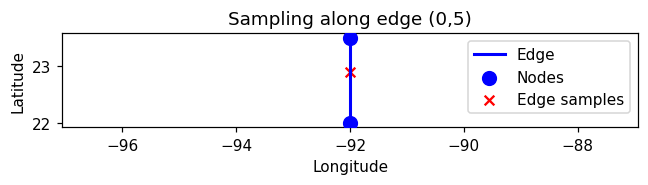

In [6]:
# Visualize sample points along one edge
u, v = path[0], path[1]
lat_u, lon_u = graph.node_coords(u)
lat_v, lon_v = graph.node_coords(v)
edge_items = [it for it in items if it.source == "edge" and it.edge in ((u, v), (v, u))]
node_items = [it for it in items if it.source == "node"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([lon_u, lon_v], [lat_u, lat_v], "b-", linewidth=2, label="Edge")
ax.scatter([lon_u, lon_v], [lat_u, lat_v], c="blue", s=80, zorder=5, label="Nodes")
if edge_items:
    ax.scatter([it.lon for it in edge_items], [it.lat for it in edge_items], c="red", s=40, marker="x", label="Edge samples")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Sampling along edge ({u},{v})")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Covariance backends

Two backends: **kernel** (RBF space-time) and **empirical** (from DataProvider snapshots).

In [7]:
from oceanbench_core import EvalGrid, build_eval_grid, Scenario
from oceanbench_models.belief.field.covariance_backends import build_covariance_backend

scenario = Scenario(
    name="binney_demo",
    variable=VARIABLE,
    region=region,
    time_range=(np.datetime64(TIME_WINDOW[0]), np.datetime64(TIME_WINDOW[1])),
    metadata={"product_id": PRODUCT_ID},
)

eval_cfg = {"grid_n_lat": 20, "grid_n_lon": 20, "max_points": 2000}
eval_grid = build_eval_grid(scenario, eval_cfg, rng=np.random.default_rng(42))

# Kernel backend
task_cfg_kernel = {
    "covariance": {
        "backend": "kernel",
        "kernel": {
            "lengthscale_space": 1.0,
            "lengthscale_time": 1.0,
            "variance": 1.0,
            "noise": 0.01,
            "fit": True,
            "fit_max_iters": 50,
            "fit_subsample_n": 512,
        },
    },
}
cov_kernel = build_covariance_backend(task_cfg_kernel)

# Empirical backend (requires eval_grid with scenario and provider)
task_cfg_empirical = {
    "covariance": {
        "backend": "empirical",
        "empirical": {"window_days": 7, "max_snapshots": 10},
    },
}
cov_empirical = build_covariance_backend(
    task_cfg_empirical, eval_grid=eval_grid, provider=provider
)

print("Kernel backend:", cov_kernel)
print("Empirical backend:", cov_empirical)

Kernel backend: <oceanbench_models.belief.field.kernel_st.KernelSTCovariance object at 0x79a5903f9e20>
Empirical backend: <oceanbench_models.belief.field.empirical_cov.EmpiricalCovarianceBackend object at 0x79a59011ac30>


/home/shafezi/Documents/Projects/Data_Provider/oceanbench/oceanbench-models/oceanbench_models/belief/field/empirical_cov.py:248: RuntimeWarning: Mean of empty slice
  mean_per_point = np.nanmean(vals, axis=0, keepdims=True)
/home/shafezi/Documents/Projects/Data_Provider/oceanbench/oceanbench-models/oceanbench_models/belief/field/empirical_cov.py:253: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)


In [8]:
# Show kernel hyperparams (fixed or fitted) and empirical settings
print("Kernel backend: RBF space-time with lengthscale_space, lengthscale_time, variance")
if hasattr(cov_kernel, "_lengthscale_space"):
    print(f"  lengthscale_space={cov_kernel._lengthscale_space:.3f}, lengthscale_time={cov_kernel._lengthscale_time:.3f}, variance={cov_kernel._variance:.3f}")
print("Empirical backend: uses window_days, stride, max_snapshots from config")
print("  (Snapshot count depends on data availability in the time window)")

Kernel backend: RBF space-time with lengthscale_space, lengthscale_time, variance
  lengthscale_space=1.000, lengthscale_time=1.000, variance=1.000
Empirical backend: uses window_days, stride, max_snapshots from config
  (Snapshot count depends on data availability in the time window)


## 6. GRG offline planning

Plan once with full budget using `run_binney_offline`.

In [9]:
from oceanbench_bench.runner import run_binney_offline

config_offline = {
    "seed": 42,
    "scenario": {
        "name": "binney_demo",
        "variable": VARIABLE,
        "region": region,
        "time_range": (np.datetime64("2014-01-01T00:00:00"), np.datetime64("2014-01-07T00:00:00")),
        "metadata": {"product_id": PRODUCT_ID},
    },
    "task": {
        "graph": {"type": "grid", "seed": 0, "grid": {"n_lat": 3, "n_lon": 3},
                 "start": {"node_id": 0}, "goal": {"node_id": 5},
        },
        "robot": {"speed_mps": 10.0},
        "sampling": {"mode": "nodes+edges", "edge_spacing_m": 20000.0, "include_nodes": True, "measurement_noise_var": 0.01},
        "time": {"dynamic": True, "tau0": "2014-01-01T00:00:00", "snap_to_provider_grid": False},
        "objective": {"type": "emse", "eval_set": "dense_grid"},
        "eval": {"grid_n_lat": 30, "grid_n_lon": 30, "max_points": 5000},
        "covariance": {"backend": "kernel", "kernel": {"lengthscale_space": 1.0, "lengthscale_time": 1.0, "variance": 1.0, "noise": 0.01, "fit": True,"fit_max_iters": 50}},
    },
    "policy": {
        "type": "grg",
        "planning": {"mode": "offline", "budget_seconds": 500_000.0, "depth": 2, "n_splits": 5},
    },
}

result_offline = run_binney_offline(config_offline)
print("Objective value:", result_offline["objective_value"])
print("Metrics:", result_offline["metrics"])

[grg] stop: recursion completed (path_len=4, depth=2)
Objective value: 0.9900990099009732
Metrics: {'rmse': 1.2271212769896702, 'mae': 0.8422389136626235}


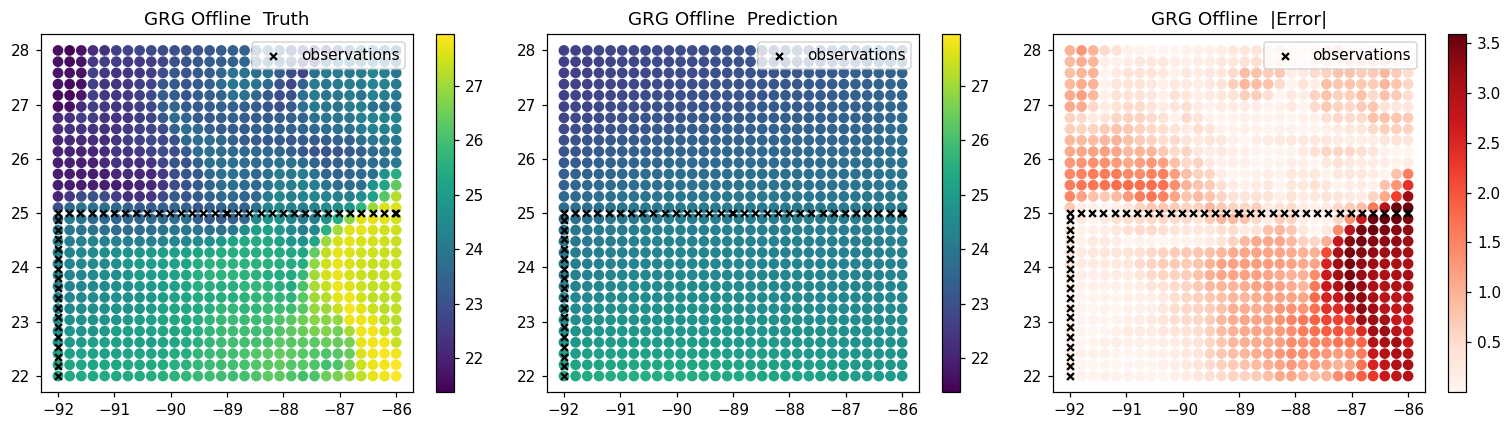

In [10]:
from oceanbench_tasks.mapping.binney_task import BinneyMappingTask
from oceanbench_env import OceanTruthField
from oceanbench_viz import plot_truth_prediction_uncertainty
from oceanbench_core import QueryPoints

task = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=config_offline["task"],
    provider=provider,
    rng=np.random.default_rng(42),
)

# Use the dataset already loaded in cell 4
truth = OceanTruthField(dataset=ds, variable=VARIABLE, scenario=task.scenario)

qp = task.eval_grid.query_points
y_true = truth.query_array(qp, method="linear", bounds_mode="clip")
# Flatten if dataset has depth dimension (use surface layer)
y_true = np.asarray(y_true, dtype=float)
if y_true.ndim > 1:
    y_true = y_true[:, 0].ravel()
else:
    y_true = y_true.ravel()

path = result_offline["path"]
if not path:
    print("Offline planner returned an empty path. Using zero field as prediction.")
    samples = []
else:
    samples = task.sample_path(path, np.datetime64("2014-01-01T00:00:00", "ns"))
from oceanbench_bench.runner import _posterior_mean_from_samples

if samples:
    qp_samp = QueryPoints(lats=[s.lat for s in samples], lons=[s.lon for s in samples], times=[s.time for s in samples])
    y_samp = truth.query_array(qp_samp, method="linear", bounds_mode="clip")
    y_pred = _posterior_mean_from_samples(task, samples, y_samp)
else:
    y_pred = np.zeros_like(y_true)

plot_truth_prediction_uncertainty(
    np.asarray(qp.lats), np.asarray(qp.lons),
    y_true, y_pred,
    obs_lats=np.array([s.lat for s in samples]) if samples else None,
    obs_lons=np.array([s.lon for s in samples]) if samples else None,
    title_prefix="GRG Offline ",
    show=True,
)

In [11]:
from oceanbench_core import QueryPoints
import numpy as np

print("len(samples) =", len(samples))

qp_samp = QueryPoints(
    lats=[s.lat for s in samples],
    lons=[s.lon for s in samples],
    times=[s.time for s in samples],
)
y_samp = truth.query_array(qp_samp, method="linear", bounds_mode="error")
y_samp = np.asarray(y_samp, dtype=float)

# If dataset has depth, keep only surface (first depth) like you do for y_true
if y_samp.ndim > 1:
    y_samp = y_samp[:, 0].ravel()
else:
    y_samp = y_samp.ravel()

print("y_samp.shape =", y_samp.shape)   # should now be (50,)

A = task.features_from_measurements(samples)
print("A.shape =", A.shape)             # (50, 3)
cov = task.covariance
Sigma_AA = cov.cov_block(A, A)
print("Sigma_AA.shape =", Sigma_AA.shape)  # (50, 50)

noise_var = float(task.sampling_config.get("measurement_noise_var", 1e-2))
alpha = np.linalg.solve(Sigma_AA + noise_var * np.eye(Sigma_AA.shape[0]), y_samp)
y_pred_at_samples = Sigma_AA @ alpha

rmse_samples = np.sqrt(np.mean((y_pred_at_samples - y_samp) ** 2))
print("RMSE at sample locations:", rmse_samples)

len(samples) = 50
y_samp.shape = (50,)
A.shape = (50, 3)
Sigma_AA.shape = (50, 50)
RMSE at sample locations: 0.3130695739337802


## 7. GRG receding-horizon planning

Plan–execute–replan loop using `run_binney_receding_horizon`.

In [12]:
from oceanbench_bench.runner import run_binney_receding_horizon

config_receding = {
    "seed": 42,
    "scenario": config_offline["scenario"],
    "task": config_offline["task"],
    "policy": {
        "type": "grg",
        "planning": {
            "mode": "receding_horizon",
            "budget_seconds": 500000.0,
            "horizon_seconds": 50000.0,
            "execute_seconds": 4000.0,
            "depth": 2,
            "n_splits": 5,
        },
    },
}

config_receding["task"]["robot"]["speed_mps"] = 200.0
config_receding["logging"] = {"enabled": True}

result_receding = run_binney_receding_horizon(config_receding)
print("Receding-horizon completed.")
print("Metrics:", result_receding.get("metrics", {}))

Running Binney receding-horizon: start=0 goal=5 budget=500000.0 horizon=50000.0 execute=4000.0
[grg] stop: recursion completed (path_len=4, depth=2)
Receding step: exec_path=[0, 3, 4] used=3179.545 current=4 remaining=496820.455
[grg] stop: recursion completed (path_len=2, depth=2)
Receding step: exec_path=[4, 5] used=1511.622 current=5 remaining=495308.833
Receding-horizon completed.
Metrics: {'rmse': 1.2545655632035309, 'mae': 0.8662876809269061}


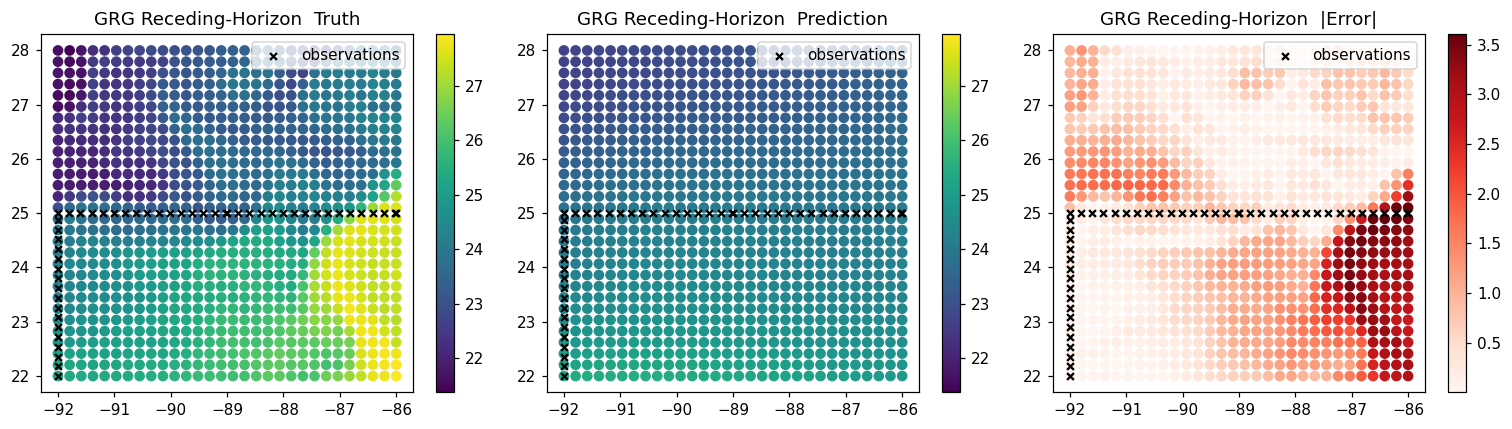

In [13]:
from oceanbench_bench.runner import _posterior_mean_from_samples

path_rh = result_receding.get("path", [])
if path_rh:
    task_rh = BinneyMappingTask.from_configs(
        scenario_cfg=config_receding["scenario"],
        task_cfg=config_receding["task"],
        provider=provider,
        rng=np.random.default_rng(42),
    )
    samples_rh = task_rh.sample_path(path_rh, np.datetime64("2014-01-01T00:00:00", "ns"))
    qp_rh = task_rh.eval_grid.query_points
    truth_rh = OceanTruthField(dataset=ds, variable=VARIABLE, scenario=task_rh.scenario)
    y_true_rh = truth_rh.query_array(qp_rh, method="linear", bounds_mode="nan")
    y_true_rh = np.asarray(y_true_rh, dtype=float)
    if y_true_rh.ndim > 1:
        y_true_rh = y_true_rh[:, 0].ravel()
    else:
        y_true_rh = y_true_rh.ravel()
    if samples_rh:
        qp_samp_rh = QueryPoints(lats=[s.lat for s in samples_rh], lons=[s.lon for s in samples_rh], times=[s.time for s in samples_rh])
        y_samp_rh = truth_rh.query_array(qp_samp_rh, method="linear", bounds_mode="nan")
        y_pred_rh = _posterior_mean_from_samples(task_rh, samples_rh, y_samp_rh)
    else:
        y_pred_rh = np.zeros_like(y_true_rh)
    plot_truth_prediction_uncertainty(
        np.asarray(qp_rh.lats), np.asarray(qp_rh.lons),
        y_true_rh, y_pred_rh,
        obs_lats=np.array([s.lat for s in samples_rh]) if samples_rh else None,
        obs_lons=np.array([s.lon for s in samples_rh]) if samples_rh else None,
        title_prefix="GRG Receding-Horizon ",
        show=True,
    )

## 8. Baseline comparisons

Compare GRG against greedy myopic, random walk, and lawnmower baselines.

In [14]:
import copy
task_cfg = copy.deepcopy(config_offline["task"])
task_cfg["robot"]["speed_mps"] = 100.0
task_tmp = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=task_cfg,
    provider=provider,
    rng=np.random.default_rng(42),
)
print("shortest_time(start, goal) =", task_tmp.graph.shortest_time(0, 5))

shortest_time(start, goal) = 9382.334080413457


In [15]:
import copy

baseline_configs = [
    {"type": "grg", "planning": {"budget_seconds": 100000.0, "depth": 2, "n_splits": 5}},
    {"type": "greedy_myopic", "max_steps": 500, "planning": {"budget_seconds": 100000.0}},
    {"type": "random_walk", "max_steps": 500, "planning": {"budget_seconds": 100000.0}},
    {"type": "lawnmower", "max_nodes": 100, "planning": {"budget_seconds": 100000.0}},
]

results_baselines = {}
for bc in baseline_configs:
    task_cfg = copy.deepcopy(config_offline["task"])
    task_cfg["robot"]["speed_mps"] = 100.0  # set speed here (applies to all planners)

    cfg = {
        "seed": 42,
        "scenario": config_offline["scenario"],
        "task": task_cfg,
        "policy": bc,
    }
    r = run_binney_offline(cfg)
    results_baselines[bc["type"]] = r
for name, r in results_baselines.items():
    print(f"{name}: obj={r['objective_value']:.16f}, RMSE={r['metrics'].get('rmse', float('nan')):.6f}")    

[grg] stop: recursion completed (path_len=4, depth=2)
[greedy_myopic] stop: reached goal node
[random_walk] stop: reached goal node
[lawnmower] stop: completed waypoint order
grg: obj=0.9900990099009732, RMSE=1.251992
greedy_myopic: obj=0.9900990099009732, RMSE=2.017757
random_walk: obj=0.9900990099009732, RMSE=1.398054
lawnmower: obj=0.9900990099009732, RMSE=2.164103


In [16]:
for name, r in results_baselines.items():
    path = r.get("path", [])
    samples = r.get("samples", [])
    print(
        f"{name}: path_len={len(path)} "
        f"samples={len(samples)} "
        f"used_time={r.get('used_budget_seconds')}"
    )

grg: path_len=4 samples=50 used_time=9382.334080413457
greedy_myopic: path_len=32 samples=498 used_time=96122.68667274517
random_walk: path_len=4 samples=50 used_time=9451.985568988717
lawnmower: path_len=9 samples=129 used_time=24794.580364719626


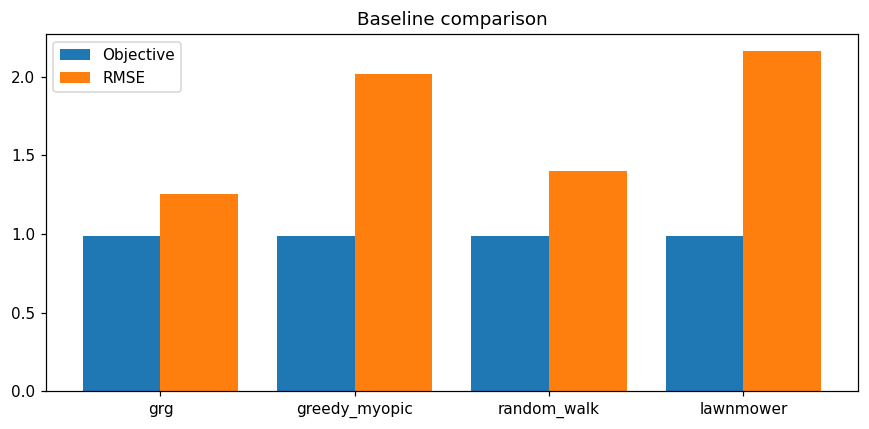

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results_baselines.keys())
objs = [results_baselines[n]["objective_value"] for n in names]
rmses = [results_baselines[n]["metrics"].get("rmse", np.nan) for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, objs, 0.4, label="Objective")
ax.bar(x + 0.2, rmses, 0.4, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_title("Baseline comparison")
plt.tight_layout()
plt.show()

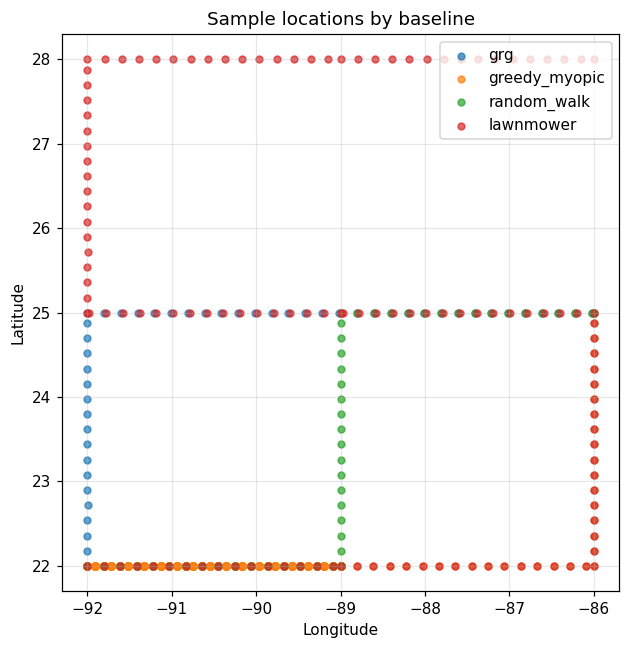

In [18]:
from oceanbench_tasks.mapping.binney_task import BinneyMappingTask
import numpy as np

# One task for all (same scenario/task config)
task_plot = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=config_offline["task"],
    provider=provider,
    rng=np.random.default_rng(42),
)
tau0 = np.datetime64(config_offline["task"]["time"]["tau0"], "ns")

fig, ax = plt.subplots(figsize=(8, 6))

colors = {"grg": "C0", "greedy_myopic": "C1", "random_walk": "C2", "lawnmower": "C3"}
for name, r in results_baselines.items():
    path = r.get("path") or []
    if not path:
        ax.scatter([], [], label=f"{name} (no path)", color=colors.get(name, "gray"), alpha=0.7)
        continue
    samples = task_plot.sample_path(path, tau0)
    if not samples:
        ax.scatter([], [], label=f"{name} (no samples)", color=colors.get(name, "gray"), alpha=0.7)
        continue
    lats = [s.lat for s in samples]
    lons = [s.lon for s in samples]
    ax.scatter(lons, lats, label=name, color=colors.get(name, "gray"), alpha=0.7, s=20)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sample locations by baseline")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Dense-grid evaluation

Evaluate prediction quality on the dense evaluation grid using RMSE and MAE.

The cell below computes RMSE and MAE on the dense evaluation grid and prints the summary.

In [19]:
# Baseline coverage diagnostics
from oceanbench_tasks.mapping.binney_task import BinneyMappingTask

# One task for all (same scenario/task config)
task_diag = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=config_offline["task"],
    provider=provider,
    rng=np.random.default_rng(42),
)

tau0 = np.datetime64(config_offline["task"]["time"]["tau0"], "ns")

sample_sets = {}
print("Baseline sample coverage summary:")
for name, r in results_baselines.items():
    path = r.get("path") or []
    if not path:
        print(f"  {name}: path_len=0")
        sample_sets[name] = set()
        continue
    samples = task_diag.sample_path(path, tau0)
    sample_xy = {(round(s.lat, 4), round(s.lon, 4)) for s in samples}
    sample_sets[name] = sample_xy
    print(
        f"  {name}: path_len={len(path)}, n_samples={len(samples)}, "
        f"uniq_sample_xy={len(sample_xy)}"
    )

names = list(sample_sets.keys())
if len(names) >= 2:
    print("Jaccard overlap (unique sample locations):")
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a = sample_sets[names[i]]
            b = sample_sets[names[j]]
            if not a and not b:
                score = 1.0
            else:
                score = len(a & b) / max(1, len(a | b))
            print(f"  {names[i]} vs {names[j]}: {score:.3f}")


Baseline sample coverage summary:
  grg: path_len=4, n_samples=50, uniq_sample_xy=50
  greedy_myopic: path_len=32, n_samples=498, uniq_sample_xy=65
  random_walk: path_len=4, n_samples=50, uniq_sample_xy=50
  lawnmower: path_len=9, n_samples=129, uniq_sample_xy=129
Jaccard overlap (unique sample locations):
  grg vs greedy_myopic: 0.018
  grg vs random_walk: 0.220
  grg vs lawnmower: 0.023
  greedy_myopic vs random_walk: 0.186
  greedy_myopic vs lawnmower: 0.347
  random_walk vs lawnmower: 0.119


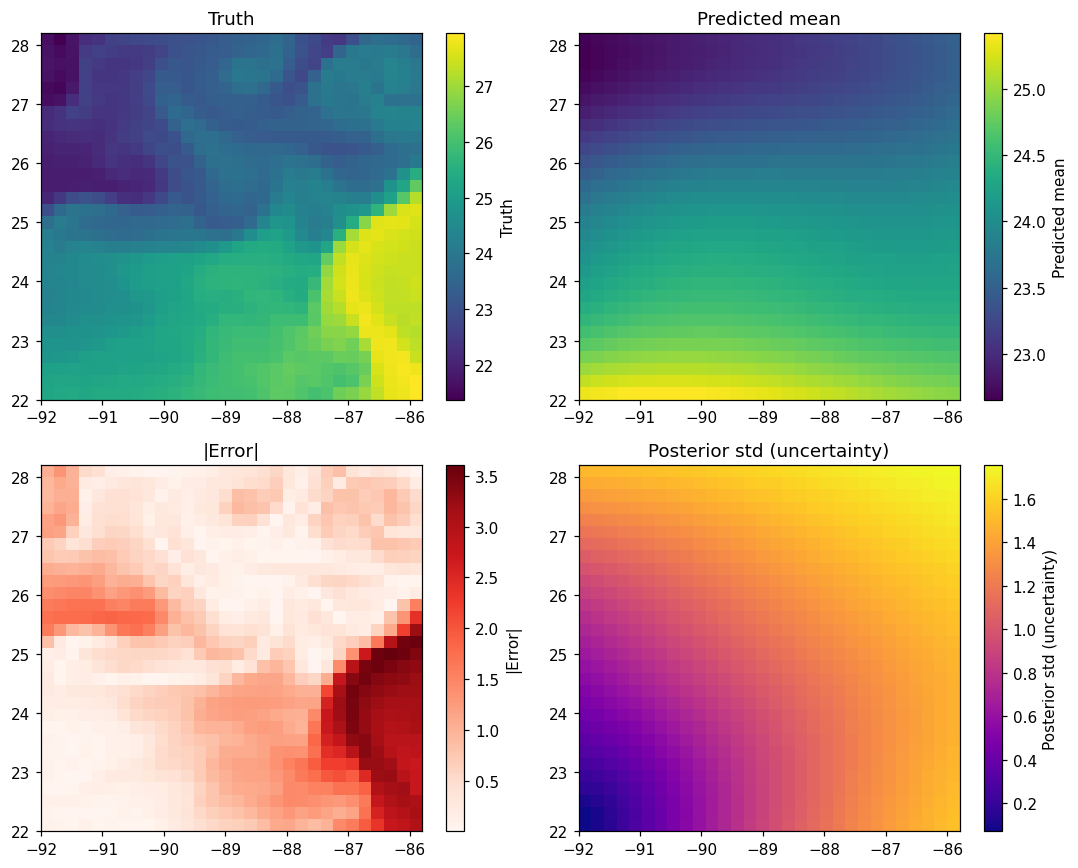

Dense-grid evaluation metrics:
  RMSE: 1.2534
  MAE:  0.8660
Dense-grid metrics: {'rmse': 1.2534489103013493, 'mae': 0.8660089233884246}


In [20]:
from oceanbench_bench.runner import _posterior_mean_from_samples
from oceanbench_viz import plot_field
from oceanbench_bench.eval import evaluate_binney_dense_grid

# --- build task + truth ---
task_eval = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=config_offline["task"],
    provider=provider,
    rng=np.random.default_rng(42),
)
truth_eval = OceanTruthField(dataset=ds, variable=VARIABLE, scenario=task_eval.scenario)
qp_eval = task_eval.eval_grid.query_points

# --- ground truth on eval grid ---
y_true_eval = truth_eval.query_array(qp_eval, method="linear", bounds_mode="nan")
y_true_eval = np.asarray(y_true_eval, dtype=float)
y_true_eval = y_true_eval[:, 0].ravel() if y_true_eval.ndim > 1 else y_true_eval.ravel()

lats_1d = np.unique(np.asarray(qp_eval.lats))
lons_1d = np.unique(np.asarray(qp_eval.lons))
n_lat, n_lon = len(lats_1d), len(lons_1d)
truth_2d = y_true_eval.reshape(n_lat, n_lon)

# --- choose method here ---
r = results_baselines["grg"]    # change to another baseline if needed
path = r["path"]
samples = task_eval.sample_path(path, np.datetime64("2014-01-01T00:00:00", "ns"))

# --- prediction on eval grid ---
if samples:
    qp_samp = QueryPoints(
        lats=[s.lat for s in samples],
        lons=[s.lon for s in samples],
        times=[s.time for s in samples],
    )
    y_samp = truth_eval.query_array(qp_samp, method="linear", bounds_mode="nan")
    y_pred_eval = _posterior_mean_from_samples(task_eval, samples, y_samp)
else:
    y_pred_eval = np.zeros_like(y_true_eval)

pred_2d = np.asarray(y_pred_eval).reshape(n_lat, n_lon)
err_2d = np.abs(truth_2d - pred_2d)

# --- posterior uncertainty (std) ---
if samples:
    A = task_eval.features_from_measurements(samples)
    Y = np.column_stack([np.asarray(qp_eval.lats, dtype=float),
                         np.asarray(qp_eval.lons, dtype=float)])
    if qp_eval.times is not None:
        t = np.asarray(qp_eval.times, dtype="datetime64[ns]").astype("int64") / 1e9
        Y = np.column_stack([Y, t.astype(float)])
    cov = task_eval.covariance
    Sigma_YY = cov.cov_block(Y, Y)
    Sigma_YA = cov.cov_block(Y, A)
    Sigma_AY = Sigma_YA.T
    Sigma_AA = cov.cov_block(A, A)
    noise_var = float(task_eval.sampling_config.get("measurement_noise_var", 0.01))
    Sigma_AA_noise = Sigma_AA + noise_var * np.eye(A.shape[0])
    K = Sigma_YA @ np.linalg.solve(Sigma_AA_noise, Sigma_AY)
    Sigma_post = Sigma_YY - K
    post_var = np.maximum(np.diag(Sigma_post), 0.0)
    post_std = np.sqrt(post_var)
else:
    post_std = np.zeros(qp_eval.size)

unc_2d = np.asarray(post_std).reshape(n_lat, n_lon)

# --- plots ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_field(truth_2d, lats_1d, lons_1d, title="Truth", ax=axes[0, 0])
plot_field(pred_2d, lats_1d, lons_1d, title="Predicted mean", ax=axes[0, 1])
plot_field(err_2d, lats_1d, lons_1d, title="|Error|", cmap="Reds", ax=axes[1, 0])
plot_field(unc_2d, lats_1d, lons_1d, title="Posterior std (uncertainty)", cmap="plasma", ax=axes[1, 1])
plt.tight_layout()
plt.show()

metrics = evaluate_binney_dense_grid(y_true=y_true_eval, y_pred=y_pred_eval, query_points=qp_eval)
print("Dense-grid evaluation metrics:")
print(f"  RMSE: {metrics['rmse']:.4f}")
print(f"  MAE:  {metrics['mae']:.4f}")
print("Dense-grid metrics:", metrics)

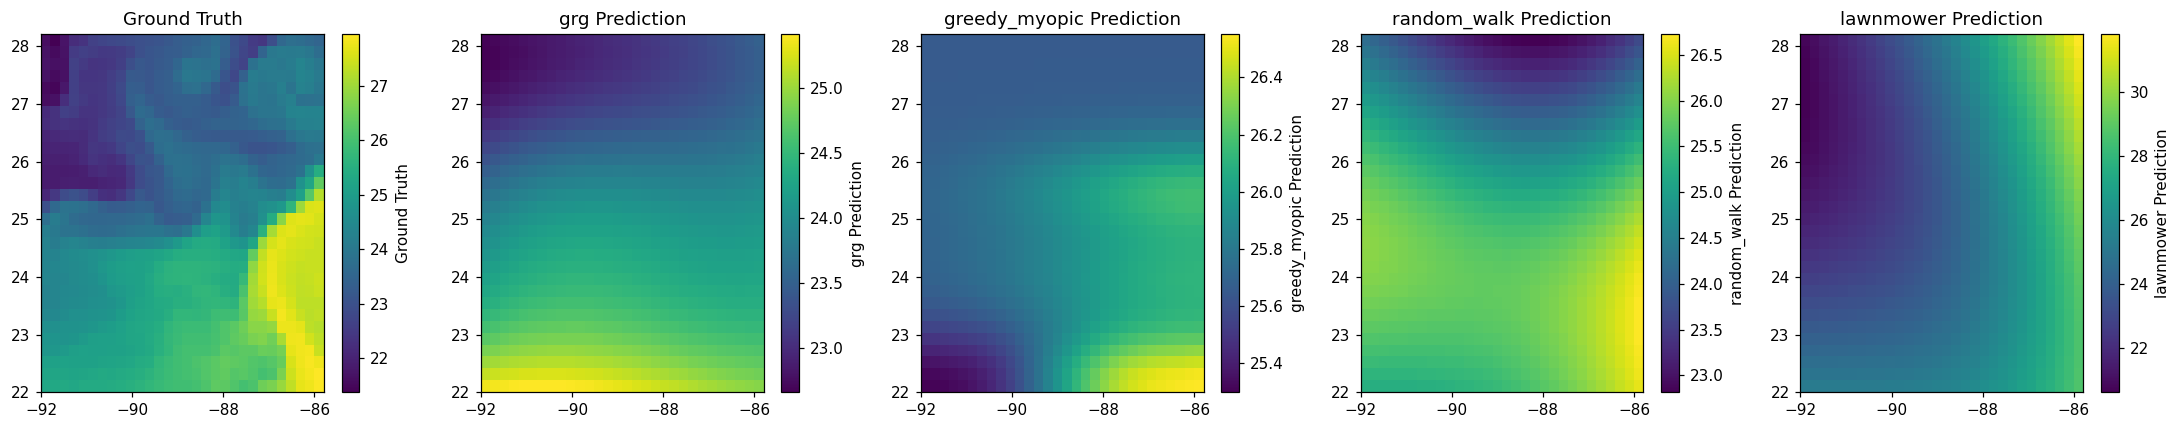

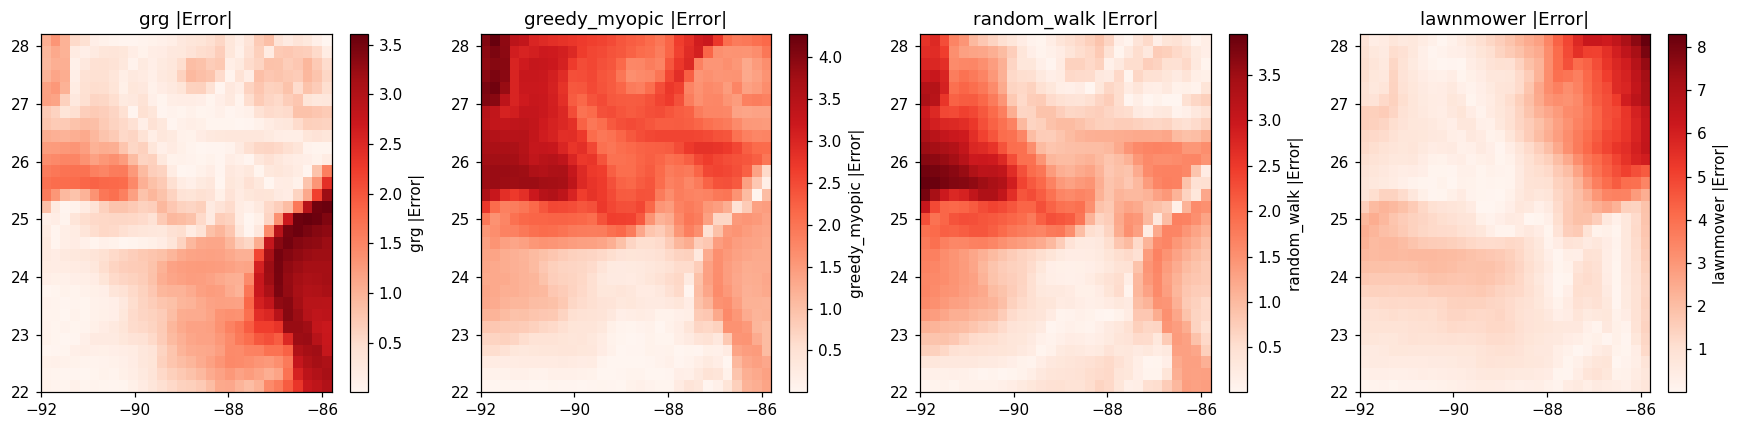

In [21]:
from oceanbench_bench.runner import _posterior_mean_from_samples
from oceanbench_viz import plot_field

methods = ["grg", "greedy_myopic", "random_walk", "lawnmower"]

# Build eval task + truth once
task_eval = BinneyMappingTask.from_configs(
    scenario_cfg=config_offline["scenario"],
    task_cfg=config_offline["task"],
    provider=provider,
    rng=np.random.default_rng(42),
)
truth_eval = OceanTruthField(dataset=ds, variable=VARIABLE, scenario=task_eval.scenario)
qp_eval = task_eval.eval_grid.query_points

# GT on eval grid
y_true_eval = truth_eval.query_array(qp_eval, method="linear", bounds_mode="nan")
y_true_eval = np.asarray(y_true_eval, dtype=float)
y_true_eval = y_true_eval[:, 0].ravel() if y_true_eval.ndim > 1 else y_true_eval.ravel()

# 1D grid → 2D reshape
lats_1d = np.unique(np.asarray(qp_eval.lats))
lons_1d = np.unique(np.asarray(qp_eval.lons))
n_lat, n_lon = len(lats_1d), len(lons_1d)
truth_2d = y_true_eval.reshape(n_lat, n_lon)

# Compute preds for each method
preds_2d = {}
errs_2d = {}
for m in methods:
    r = results_baselines[m]
    path = r["path"]
    samples = task_eval.sample_path(path, np.datetime64("2014-01-01T00:00:00", "ns"))
    if samples:
        qp_samp = QueryPoints(
            lats=[s.lat for s in samples],
            lons=[s.lon for s in samples],
            times=[s.time for s in samples],
        )
        y_samp = truth_eval.query_array(qp_samp, method="linear", bounds_mode="nan")
        y_pred = _posterior_mean_from_samples(task_eval, samples, y_samp)
    else:
        y_pred = np.zeros_like(y_true_eval)

    pred_2d = np.asarray(y_pred).reshape(n_lat, n_lon)
    preds_2d[m] = pred_2d
    errs_2d[m] = np.abs(truth_2d - pred_2d)

# --- Plot: GT + Predictions ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
plot_field(truth_2d, lats_1d, lons_1d, title="Ground Truth", ax=axes[0])
for i, m in enumerate(methods, start=1):
    plot_field(preds_2d[m], lats_1d, lons_1d, title=f"{m} Prediction", ax=axes[i])
plt.tight_layout()
plt.show()

# --- Plot: Errors for all 4 methods ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, m in enumerate(methods):
    plot_field(errs_2d[m], lats_1d, lons_1d, title=f"{m} |Error|", cmap="Reds", ax=axes[i])
plt.tight_layout()
plt.show()

In [22]:
# # --- Time vs no-time comparison (self-contained) ---
# from oceanbench_tasks.mapping.binney_task import BinneyMappingTask
# from oceanbench_bench.runner import _posterior_mean_from_samples
# from oceanbench_core.sampling import MeasurementItem
# from oceanbench_core import QueryPoints

# # Build separate tasks so covariance fitting doesn't interfere
# rng = np.random.default_rng(42)
# task_time = BinneyMappingTask.from_configs(
#     scenario_cfg=config_offline["scenario"],
#     task_cfg=config_offline["task"],
#     provider=provider,
#     rng=rng,
# )
# task_notime = BinneyMappingTask.from_configs(
#     scenario_cfg=config_offline["scenario"],
#     task_cfg=config_offline["task"],
#     provider=provider,
#     rng=np.random.default_rng(42),
# )

# # Pick a path from a previous run (offline or baselines)
# path = None
# if "result_offline" in globals() and result_offline.get("path"):
#     path = result_offline["path"]
# elif "results_baselines" in globals() and results_baselines.get("grg", {}).get("path"):
#     path = results_baselines["grg"]["path"]
# else:
#     raise ValueError("No path found. Run offline/baseline planning first.")

# # Sample with time
# samples_time = task_time.sample_path(path, np.datetime64("2014-01-01T00:00:00", "ns"))

# # Same samples but with time removed
# samples_notime = [
#     MeasurementItem(
#         lat=s.lat,
#         lon=s.lon,
#         time=None,
#         depth=s.depth,
#         source=s.source,
#         node_index=s.node_index,
#         edge=s.edge,
#         alpha=s.alpha,
#     )
#     for s in samples_time
# ]

# # Query truth at time-aware samples
# qp_samp = QueryPoints(
#     lats=[s.lat for s in samples_time],
#     lons=[s.lon for s in samples_time],
#     times=[s.time for s in samples_time],
# )
# y_samp = truth.query_array(qp_samp, method="linear", bounds_mode="nan")

# # Posterior mean using time vs no-time features
# y_pred_time = _posterior_mean_from_samples(task_time, samples_time, y_samp)
# y_pred_notime = _posterior_mean_from_samples(task_notime, samples_notime, y_samp)

# # Compare
# print("First 3 sample times:", [s.time for s in samples_time[:3]])
# print("Feature dims with time:", task_time.features_from_measurements(samples_time).shape[1])
# print("Feature dims without time:", task_notime.features_from_measurements(samples_notime).shape[1])

# mean_abs_diff = float(np.mean(np.abs(y_pred_time - y_pred_notime)))
# print("Mean |prediction_time - prediction_no_time|:", mean_abs_diff)
